# TensorFlow를 활용한 선형회귀 실습

이 노트북에서는 TensorFlow를 사용하여 간단한 선형회귀 문제를 풀어봅니다.

## 주요 단계
1. 데이터 생성 (y = 3x + 2 + 잡음)
2. 모델 정의 (Dense Layer)
3. 손실 함수 및 최적화 방법 설정
4. 학습 진행 및 시각화


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.19.0


## 1. 데이터 생성

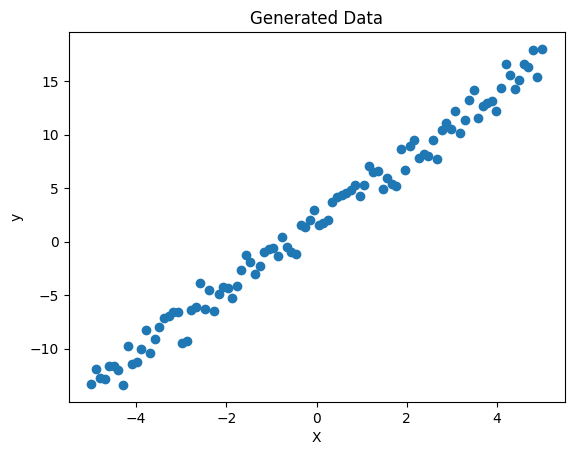

In [ ]:
# y = 3x + 2 + noise
n_samples = 100
X = np.linspace(-5, 5, n_samples)
y = 3 * X + 2 + np.random.normal(0, 1, n_samples)

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Generated Data")
plt.show()

## 2. 모델 정의

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(1,)),
    tf.keras.layers.Dense(1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

## 3. 모델 컴파일
- 손실 함수: MSE (Mean Squared Error)
- 최적화 방법: SGD (Stochastic Gradient Descent)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
              loss='mse')

## 4. 모델 학습

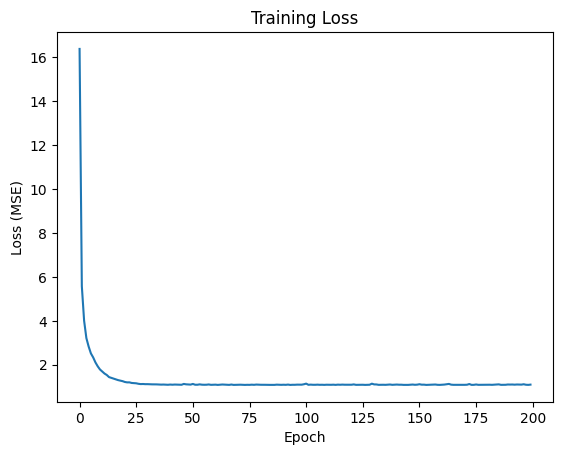

In [ ]:
history = model.fit(X, y, epochs=200, verbose=0)

plt.plot(history.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss')
plt.show()

## 5. 결과 확인

학습된 기울기 W: 3.057, 절편 b: 1.822
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


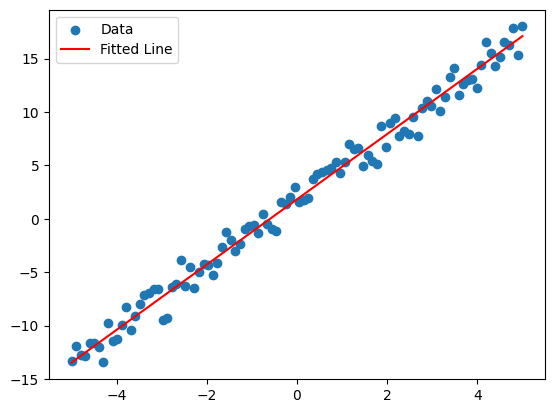

In [ ]:
W, b = model.layers[0].get_weights()
print(f"학습된 기울기 W: {W[0][0]:.3f}, 절편 b: {b[0]:.3f}")

y_pred = model.predict(X)

plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Fitted Line')
plt.legend()
plt.show()

## 생각해보기
- 학습 샘플 수가 작아지면 어떻게 되는가?
    - **과적합(Overfitting) 위험 증가**: 적은 데이터로는 모델이 일반적인 패턴보다는 특정 데이터의 잡음까지 학습할 가능성이 높아집니다.
    - **추정 정확도 감소**: 모집단의 실제 관계(y = 3x + 2)를 정확히 파악하기 어려워져 기울기와 절편의 추정값이 실제값에서 벗어날 수 있습니다.
    - **분산(Variance) 증가**: 동일한 크기의 다른 샘플로 학습할 때마다 결과가 크게 달라질 수 있습니다.
    - **통계적 신뢰성 저하**: 충분한 샘플이 없으면 중심극한정리의 효과를 얻기 어려워 안정적인 학습이 힘듭니다.

- 학습 샘플에 잡음이 많으면 어떻게 되는가? 이 경우 학습 데이터가 많이 필요한가?
    - **신호 대 잡음 비율(SNR) 감소**: 잡음이 많아지면 실제 패턴(신호)을 찾기 어려워집니다.
    - **학습 불안정성**: 잡음 때문에 모델이 실제 관계가 아닌 무작위 변동을 학습하려 할 수 있습니다.
    - **더 많은 데이터의 필요성**:
        - **대수의 법칙**: 샘플 수가 증가하면 잡음의 영향은 평균적으로 상쇄되어 실제 패턴이 드러납니다.
        - **표준오차 감소**: 샘플 크기가 n일 때 표준오차는 σ/√n으로 감소하므로, 잡음이 클수록 더 많은 데이터가 필요합니다.
        - **통계적 파워 향상**: 잡음이 많은 환경에서도 충분한 데이터가 있으면 실제 관계를 신뢰성 있게 추정할 수 있습니다.
    
  